# Frequency of Volatile-Rich Zones vs. Distance from Lander

In [2]:
# general setup: import packages and libraries and whatnot
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [6]:
# create a function to read file
def load_final_marsquakes_df(filename): #take filename as only input
    
    # these are the column names used in the file
    cols = ['Event_ID', 'Distance_Degrees', 'Distance_KM', 't0', 'tp', 'ts', 'Vp_Vs_Ratio']
    
    # dataframe from csv (access by filename, column names separated by ',', skip the first row (column names) to skip to the data)
    df = pd.read_csv(filename, sep=',', names=cols, on_bad_lines='skip', skiprows= 1)

    # give the data frame (column names and data sorted into rows)
    return df

# use file path to access the csv (go backwards, then to data, then to specific file)
df_a = load_final_marsquakes_df('../data/final_marsquakes_data_frame.csv')
# create a new dataframe for potential volatile zones from just the Vp/Vs ratios between 1.8 and 2.1 - these are what we determined to be abnormalities compared to dry rock (see other notebooks for more explaination)
volatile_zone = df_a[(df_a['Vp_Vs_Ratio'] >= 1.80) & (df_a['Vp_Vs_Ratio'] <= 2.10)].copy() #copy makes a new dataframe instead of changing the old one
volatile_zone= volatile_zone[(volatile_zone['Distance_KM']<=3000)] #get rid of outliers - we could see from using all the distances that most of the data was less than 3000 km, with 2-3 outliers
# removing outliers gives us a more detailed look at where probabilites are highest because we get to zoom in on the "important" part of the plot

# depth is ~12% of the surface distance, didn't end up using this, but you would if you wanted a plot for most probable depths to find volatile-rich zones
volatile_zone['Est_Depth_KM'] = volatile_zone['Distance_KM'] * 0.12

# let's see the first 10 rows!
volatile_zone.head(10)

,Event_ID,Distance_Degrees,Distance_KM,t0,tp,ts,Vp_Vs_Ratio,Est_Depth_KM
10,S0820a,30.19,1787.248,2021-03-18T14:51:33.869889Z,2021-03-18T14:54:39.0Z,2021-03-18T14:57:39.0Z,1.972289,214.46976
14,S1197a,31.98,1893.216,2022-04-09T22:05:52.41687Z,2022-04-09T22:09:38.5Z,2022-04-09T22:12:49.0Z,1.842610,227.18592
15,S1192a,25.50,1509.600,2022-04-04T23:06:52.616746Z,2022-04-04T23:12:12.572401Z,2022-04-04T23:16:48.265836Z,1.861661,181.15200
16,S1163a,23.10,1367.520,2022-03-06T02:29:13.668752Z,2022-03-06T02:34:18.697973Z,2022-03-06T02:38:28.753599Z,1.819776,164.10240
23,S1094d,24.40,1444.480,2021-12-25T03:31:41.685086Z,2021-12-25T03:36:52.573319Z,2021-12-25T03:41:16.658691Z,1.849454,173.33760
27,S1086d,24.90,1474.080,2021-12-16T23:02:32.671075Z,2021-12-16T23:07:42.4055Z,2021-12-16T23:12:11.468547Z,1.868690,176.88960
29,S1077c,23.00,1361.600,2021-12-07T14:01:49.15588Z,2021-12-07T14:06:59.285347Z,2021-12-07T14:11:08.381859Z,1.803202,163.39200
30,S1075c,25.60,1515.520,2021-12-05T14:43:47.693762Z,2021-12-05T14:49:10.902171Z,2021-12-05T14:53:48.242672Z,1.858086,181.86240
31,S1073d,26.50,1568.800,2021-12-03T14:28:52.584603Z,2021-12-03T14:33:57.521266Z,2021-12-03T14:38:44.069111Z,1.939696,188.25600
32,S1071b,25.00,1480.000,2021-12-01T12:19:05.491437Z,2021-12-01T12:24:25.3756Z,2021-12-01T12:28:55.650274Z,1.844914,177.60000


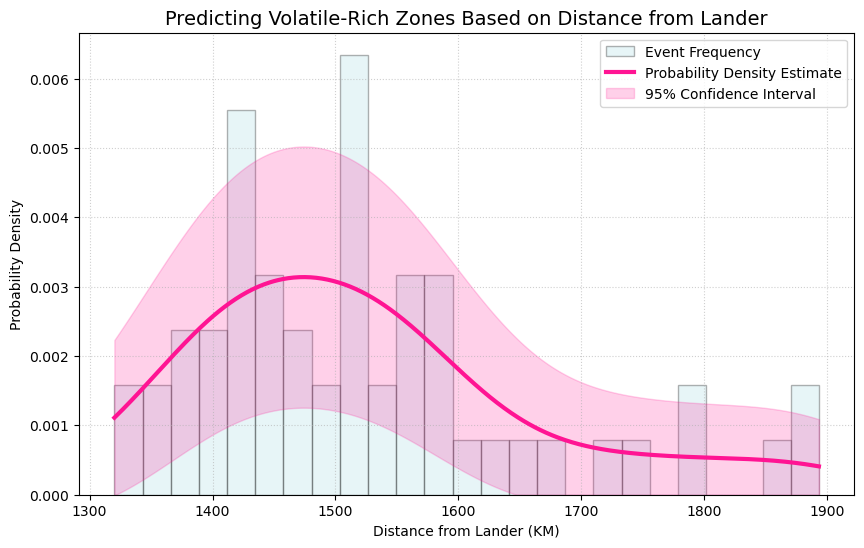

In [ ]:

dist = volatile_zone['Distance_KM'].values # creates a vector containing all the distance values
n = len(dist) # n is the number of observations we have
color = 'deeppink' # hello women in stem!

fig, ax1 = plt.subplots(figsize=(10, 6)) # basic setup of the plot

# create the histogram using 25 bins to separate the distances into
# density= true makes the area under the curve 1, which means the area of each bar represents the probability that a data point falls within the bin's range of distances (basically makes the y-axis probability density)
# rest of the command is just visuals (colors, lines, making things pretty!)
n_hist, bins, patches = ax1.hist(dist, bins=25, density=True, color='powderblue', 
                                 edgecolor='black', alpha=0.3, label='Event Frequency')

# the trendline
kde = gaussian_kde(dist) #kde is kernel density estimation from the scipy library. this one uses gaussian quadrature/ lets the data determine the shape instead of assuming a specific shape
dist_range = np.linspace(min(dist), max(dist), 500) # create a linearly spaced vector with 500 entries from the min to max values
trend_density = kde(dist_range) # heres the trendline!

# confidence interval
z_score = 1.96 # the z-score for 2 standard deviations from the mean (ie a 95% CI)
bandwidth = kde.factor * np.std(dist) # scipy's internal smoothing factor
std_err = np.sqrt(trend_density / (n * bandwidth)) # calculate the standard error at every point from the basic formula
ci = z_score * std_err # confidence interval (this will be +/- the trend density everywhere)
# the way we did this means theres a 95% confidence interval for every point

# plotting the trendline
ax1.plot(dist_range, trend_density, color=color, linewidth=3, label='Probability Density Estimate')

# fill in the confidence interval
ax1.fill_between(dist_range, 
                 np.maximum(0, trend_density - ci), # heres the part where its CI +/- trend density
                 trend_density + ci, 
                 color=color, alpha=0.2, label='95% Confidence Interval')
# we are 95% confident that the true distribution of volatile-rich zones lies within the shaded pink region, assuming the data represents a random sampling of marsquakes.

# the final visual details
ax1.set_title('Predicting Volatile-Rich Zones Based on Distance from Lander', fontsize=14)
ax1.set_xlabel('Distance from Lander (KM)')
ax1.set_ylabel('Probability Density')
ax1.grid(ls='dotted', alpha=0.6)
ax1.legend()

plt.show()